In [1]:
!pip install numpy
!pip install scikit-image
!pip install scikit-learn
!pip install matplotlib

Shape of first image: (2359296,)


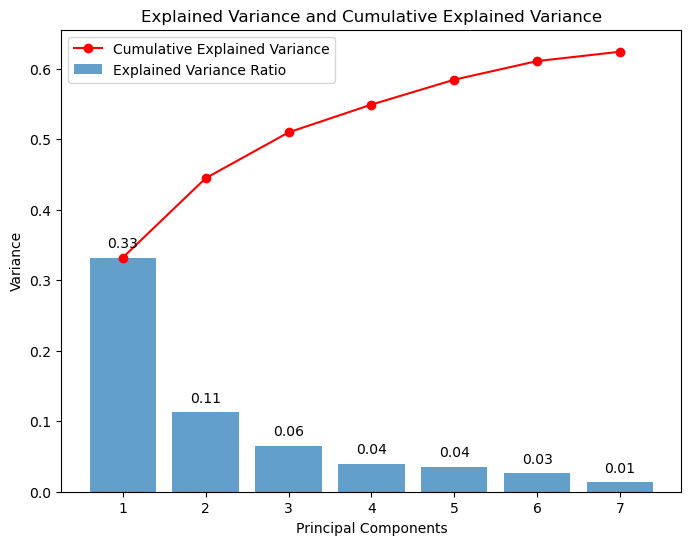

Number of components needed to explain 95.0% of variance (filtered): 1


In [15]:
import os
import numpy as np
from skimage import io
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D

def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        if filename.endswith('.tif'):
            img = io.imread(os.path.join(folder, filename))
            
            # Ensure the image has 9 channels (e.g., multi-spectral or multi-layered)
            if img.ndim == 3 and img.shape[2] == 9:  # Check if there are exactly 9 channels
                # Flatten each image into a 1D array of 9 components
                img = img.reshape(-1, 9)  # Flattening to a 2D array (pixels x channels)
            elif img.ndim == 2:  # If it's grayscale, we'll treat it as a single channel
                img = img.flatten().reshape(-1, 1)  # Flatten to 1D and reshape to (pixels x 1 channel)
            
            images.append(img)
    return np.array(images)

# Path to the folder containing the .tif images
folder_path = 'home/temp'

# Load images from the folder
images = load_images_from_folder(folder_path)

# Reshape the data to (number_of_images, pixels * channels)
images = images.reshape(len(images), -1)

print(f"Shape of first image: {images[0].shape}")

# Standardize the features
scaler = StandardScaler()
images_scaled = scaler.fit_transform(images)

# Perform PCA on the images' 9 channels/features
pca = PCA(n_components=9)  # We want to keep all 9 components initially
pca_result = pca.fit_transform(images_scaled)

# Check the explained variance and cumulative variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Remove 7th and 8th components by ignoring the 6th and 7th index (0-based)
explained_variance_ratio_filtered = np.delete(explained_variance_ratio, [6, 7])
cumulative_variance_filtered = np.cumsum(explained_variance_ratio_filtered)

# Create a single figure to overlay the graphs
plt.figure(figsize=(8, 6))

# Plot the explained variance ratio for each principal component (filtered)
bars = plt.bar(range(1, len(explained_variance_ratio_filtered) + 1), explained_variance_ratio_filtered, label='Explained Variance Ratio', alpha=0.7)

# Plot the cumulative explained variance (filtered)
plt.plot(range(1, len(cumulative_variance_filtered) + 1), cumulative_variance_filtered, marker='o', linestyle='-', color='r', label='Cumulative Explained Variance')

# Add text annotations for the bars to display the values on the graph
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.2f}', ha='center', va='bottom')

# Create the legend elements using the array (arbitrary items unrelated to graph)
items = [(1, 'Red'), (2, 'Green'), (3, 'Blue'),(4, 'NIR'), (5, 'Ndvi'), (6, 'Wetness'), (7, 'Hillshade')]
legend_elements = [Line2D([0], [0], color='black', lw=2, label=f'{num}: {name}') for num, name in items]

# Add both legends to the plot
plt.legend(handles=legend_elements, loc='upper right')
plt.legend(loc='upper left')  # The existing legend for explained variance

# Add labels and title
plt.title('Explained Variance and Cumulative Explained Variance')
plt.xlabel('Principal Components')
plt.ylabel('Variance')

# Show the plot
plt.show()

# Optional: Determine how many components are needed to explain a threshold (e.g., 95%) of the variance
threshold = 0.95
num_components_needed = np.argmax(cumulative_variance_filtered >= threshold) + 1
print(f"Number of components needed to explain {threshold*100}% of variance (filtered): {num_components_needed}")


In [30]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 151.0 MB/s eta 0:00:0000:0100:01


In [33]:
import cv2
import numpy as np

input_path = "data/train/images/SCC_NAIP_1m_patch24-14.tif"
output_path = "data/train/pngs/SCC_NAIP_1m_patch24-14.png"

# Try reading the .tif file using OpenCV
img = cv2.imread(input_path, cv2.IMREAD_UNCHANGED)

if img is None:
    print(f"Failed to open the image: {input_path}")
else:
    # Check the data type of the image
    print(f"Original image dtype: {img.dtype}")
    
    # Normalize the image if it's in float64 or float32
    if img.dtype == np.float64 or img.dtype == np.float32:
        # Normalize to the range 0-255 and convert to uint8
        img = np.clip(img * 255.0, 0, 255).astype(np.uint8)
    
    # Save as .png
    cv2.imwrite(output_path, img)
    print(f"Image saved as {output_path}")


Original image dtype: float64
Image saved as data/train/pngs/SCC_NAIP_1m_patch24-14.png


Shape of first image: (2097152,)


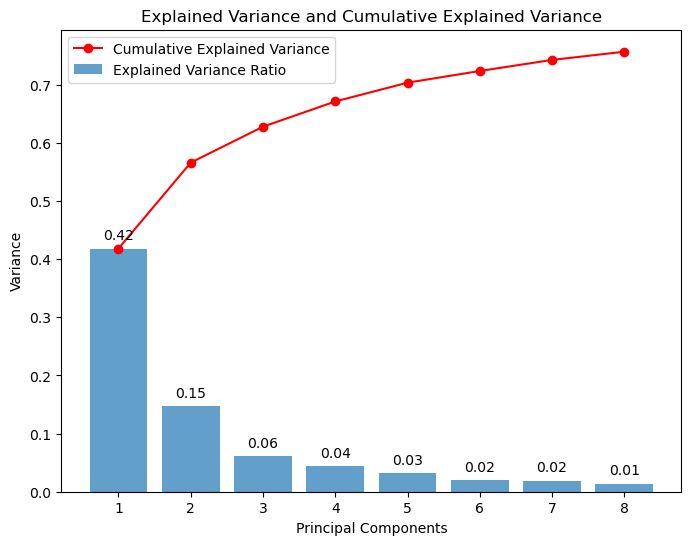

Number of components needed to explain 95.0% of variance: 1


In [3]:
import os
import numpy as np
from skimage import io
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D

def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        if filename.endswith('.tif'):
            img = io.imread(os.path.join(folder, filename))
            
            # Ensure the image has 8 channels
            if img.ndim == 3 and img.shape[2] == 8:
                img = img.reshape(-1, 8)  # Flatten to (pixels x channels)
            elif img.ndim == 2:  # If grayscale, reshape to single channel
                img = img.flatten().reshape(-1, 1)
            
            images.append(img)
    return np.array(images)

# Path to the folder containing the .tif images
folder_path = 'data/test/smashedData'

# Load images from the folder
images = load_images_from_folder(folder_path)

# Reshape the data to (number_of_images, pixels * channels)
images = images.reshape(len(images), -1)

print(f"Shape of first image: {images[0].shape}")

# Standardize the features
scaler = StandardScaler()
images_scaled = scaler.fit_transform(images)

# Perform PCA on all 8 channels
pca = PCA(n_components=8)  # Keep all 8 components
pca_result = pca.fit_transform(images_scaled)

# Explained variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Create a figure for visualization
plt.figure(figsize=(8, 6))

# Bar plot for explained variance ratio
bars = plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.7, label='Explained Variance Ratio')

# Line plot for cumulative explained variance
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-', color='r', label='Cumulative Explained Variance')

# Add text annotations for the bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.2f}', ha='center', va='bottom')

# Legend for PCA components (arbitrary channel labels)
items = [(1, 'Red'), (2, 'Green'), (3, 'Blue'), (4, 'NIR'), (5, 'NDVI'), (6, 'Wetness'), (7, 'Hillshade'), (8, 'Texture')]
legend_elements = [Line2D([0], [0], color='black', lw=2, label=f'{num}: {name}') for num, name in items]
plt.legend(handles=legend_elements, loc='upper right')
plt.legend(loc='upper left')  # Keep existing legend for variance

# Labels and title
plt.title('Explained Variance and Cumulative Explained Variance')
plt.xlabel('Principal Components')
plt.ylabel('Variance')
plt.show()

# Determine how many components explain 95% variance
threshold = 0.95
num_components_needed = np.argmax(cumulative_variance >= threshold) + 1
print(f"Number of components needed to explain {threshold*100}% of variance: {num_components_needed}")
